# Script to Load Raw Data and Filter


In [66]:
#imports
import pandas as pd
import matplotlib.pyplot as plt


# Main Takeaways:
- We have data for Los Angeles County, Austin, and Louisville.
- The dataset is unbalanced (many more LA County observations).
- We have these consistent columns through each of these three datasets
    - INSPECTION_DATE
    - STORE_NAME
    - STREET_ADDRESS
    - CITY
    - ZIP5
    - SERVICE_DESCRIPTION (This is the type of inspection, routine or other)
    - SCORE (out of 100)
    - GRADE

Using the shared years between datasets, we could feasibly create a dataset that is like this

| INSPDATE_YEAR | Count (LA County) | Count (Austin) | Count (Louisville) |
|---------------|-------------------|----------------|---------------------|
| 2022          | 37,680            | 6,939          | N/A                 |
| 2023          | 37,999            | 7,385          | 2,900               |
| 2024          | 37,643            | 6,777          | 8,523               |





# Los Angeles County Dataset

Description of dataset:
- Has data for 2022-2025 (pretty consistent year over year, much less data for 2025)
- Columns: INSPECTION_DATE, STORE_NAME, STREET_ADDRESS, CITY, ZIP5, SERVICE_DESCRIPTION, SCORE, GRADE

| INSPDATE_YEAR | Count  |
|---------------|--------|
| 2022          | 37,680 |
| 2023          | 37,999 |
| 2024          | 37,643 |
| 2025          |  8,741 |

Link to data: https://data.lacounty.gov/datasets/lacounty::environmental-health-restaurant-and-market-inspections-04-01-2022-to-03-31-2025/about

In [55]:
raw_lac = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/LACounty_Environmental_Health_Restaurant_and_Market_Inspections.csv", encoding="ISO-8859-1")

/var/folders/81/w_61xz297rv4ggdktb58tlxm0000gn/T/ipykernel_14584/1126227898.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_lac = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/LACounty_Environmental_Health_Restaurant_and_Market_Inspections.csv", encoding="ISO-8859-1")


In [56]:
#view cols
print(raw_lac.columns.tolist())


['ACTIVITY DATE', 'OWNER ID', 'OWNER NAME', 'FACILITY ID', 'FACILITY NAME', 'RECORD ID', 'PROGRAM NAME', 'PROGRAM STATUS', 'PROGRAM ELEMENT', 'PE DESCRIPTION', 'FACILITY ADDRESS', 'FACILITY CITY', 'FACILITY STATE', 'FACILITY ZIP', 'SERVICE CODE', 'SERVICE DESCRIPTION', 'SCORE', 'GRADE', 'SERIAL NUMBER', 'EMPLOYEE ID']


In [57]:
#drop unneeded columns
lac_colstokeep = ["ACTIVITY DATE", "FACILITY NAME", "FACILITY ADDRESS", "FACILITY CITY", "FACILITY ZIP", "SERVICE DESCRIPTION", "SCORE", "GRADE"]
lac_fewercols = raw_lac[lac_colstokeep]

In [61]:
#rename cols
lac_renamedict = {
    'ACTIVITY DATE': 'INSPECTION_DATE',
    'FACILITY NAME': 'STORE_NAME',
    'FACILITY ADDRESS': 'STREET_ADDRESS',
    'FACILITY CITY': 'CITY',
    'FACILITY ZIP': 'ZIP5',
    'SERVICE DESCRIPTION': 'SERVICE_DESCRIPTION',
    'SCORE': 'SCORE',
    'GRADE': 'GRADE'
}
lac_renamed = lac_fewercols.rename(columns=lac_renamedict)

In [64]:
#Clean dates
#convert "INSPECTION_DATE" to datetime
lac_renamed['INSPECTION_DATE'] = pd.to_datetime(
    lac_renamed['INSPECTION_DATE'].str.strip(),
    format='%m/%d/%Y'
)
#Creating new column with Year of Inspection Date
lac_renamed.loc[:,'INSPDATE_YEAR'] = lac_renamed['INSPECTION_DATE'].dt.year


In [65]:
#counts per year
lac_yearly_counts = lac_renamed.groupby('INSPDATE_YEAR').size()
# Display the result
print(lac_yearly_counts)

INSPDATE_YEAR
2022    37680
2023    37999
2024    37643
2025     8741
dtype: int64


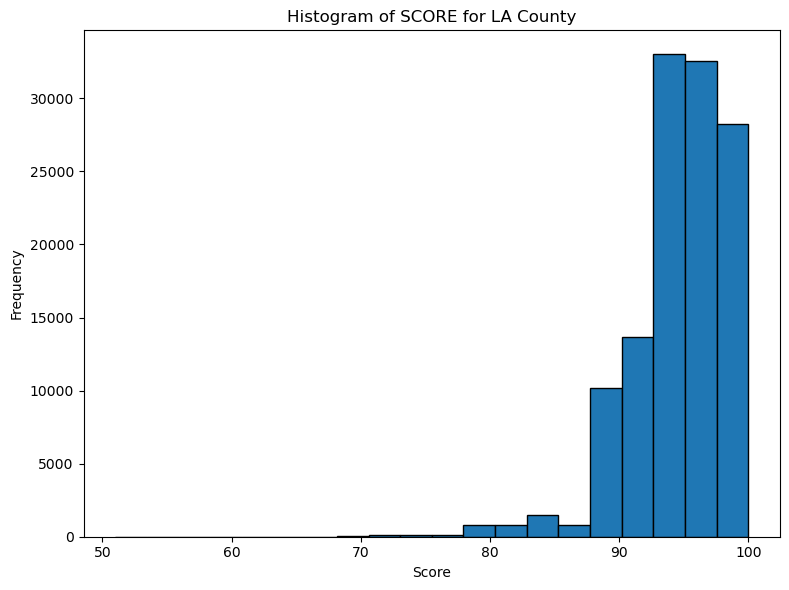

In [68]:
plt.figure(figsize=(8, 6))
lac_renamed['SCORE'].dropna().hist(bins=20, edgecolor='black')

plt.title('Histogram of SCORE for LA County')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(False)
plt.tight_layout()
plt.show()

# Louisville Metro Area Dataset

Toplines:
- Do we want to filter out certain types of restaurants/stores in the datasets? (Such as schools, day cares, nursing homes)?
- Only have data for 2023 and 2024

| INSPDATE_YEAR | Count |
|---------------|-------|
| 2023          | 2,800 |
| 2024          | 8,523 |


Link: https://catalog.data.gov/dataset/louisville-metro-ky-restaurant-inspection-scores


In [69]:
raw_lky = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/Louisville_Metro_KY_-_Restaurant_Inspection_Scores.csv")

In [ ]:
# filter out schools and day cares?
raw_lky['TypeDescription'].value_counts()

TypeDescription
FOOD SERVICE                                  5696
RETAIL-FOOD  10,000 SQ FT OR LESS             1552
TEMPORARY FOODS                               1182
FOOD SERVICE (DAY CARE / CHILD CARE CENTER     525
SELF-CONTAINED MOBILE FOOD UNITS               449
PRE-PACKAGED RETAIL                            420
SCHOOL CAFETERIA OR FOOD SERVICE               406
RETAIL-FOOD  10,001 SQ FT OR OVER              283
FOOD SERVICE (HOSPITAL / NURSING HOME          191
SUPERMARKET WITH PROCESSING                    123
FOOD SERVICE COMMISSARY                        108
STATIONARY RESTRICTED CONCESSON                 96
CATERERS                                        95
MOBILE RETAIL UNIT                              77
MOBILE RESTRICTED CONCESSION                    57
RETAIL BAKERY                                   38
RETAIL WITH LIMITED SERVICE                     12
MEAT MARKET (INCLUDING POULTRY)                  6
FARMERS MARKET TEMPORARY                         5
SPECIALTY RETAI

In [71]:
#drop unneeded columns
lky_colstokeep = ["Ins_TypeDesc", "EstablishmentName", "Address", "City", "State", "Zip", "TypeDescription", "InspectionDate", "score", "Grade"]
lky_fewercols = raw_lky[lky_colstokeep]

In [74]:
#rename cols
lky_renamedict = {
    'Ins_TypeDesc': 'LKY_INSP_TYPEDESC',
    'InspectionDate': 'INSPECTION_DATE',
    'EstablishmentName': 'STORE_NAME',
    'Address': 'STREET_ADDRESS',
    'City': 'CITY',
    'Zip': 'ZIP5',
    'score': 'SCORE',
    'Grade': 'GRADE'
}
lky_renamed = lky_fewercols.rename(columns=lky_renamedict)

In [78]:
lky_renamed.dtypes

LKY_INSP_TYPEDESC    object
STORE_NAME           object
STREET_ADDRESS       object
CITY                 object
State                object
ZIP5                  int64
TypeDescription      object
INSPECTION_DATE      object
SCORE                 int64
GRADE                object
dtype: object

In [81]:
#Clean dates
#convert "INSPECTION_DATE" to datetime
lky_renamed['INSPECTION_DATE'] = pd.to_datetime(
    lky_renamed['INSPECTION_DATE'],
    format='%Y/%m/%d %H:%M:%S'
)
#Creating new column with Year of Inspection Date
lky_renamed.loc[:,'INSPDATE_YEAR'] = lky_renamed['INSPECTION_DATE'].dt.year

In [83]:
#counts per year
lky_yearly_counts = lky_renamed.groupby('INSPDATE_YEAR').size()
# Display the result
print(lky_yearly_counts)

INSPDATE_YEAR
2023    2800
2024    8523
dtype: int64


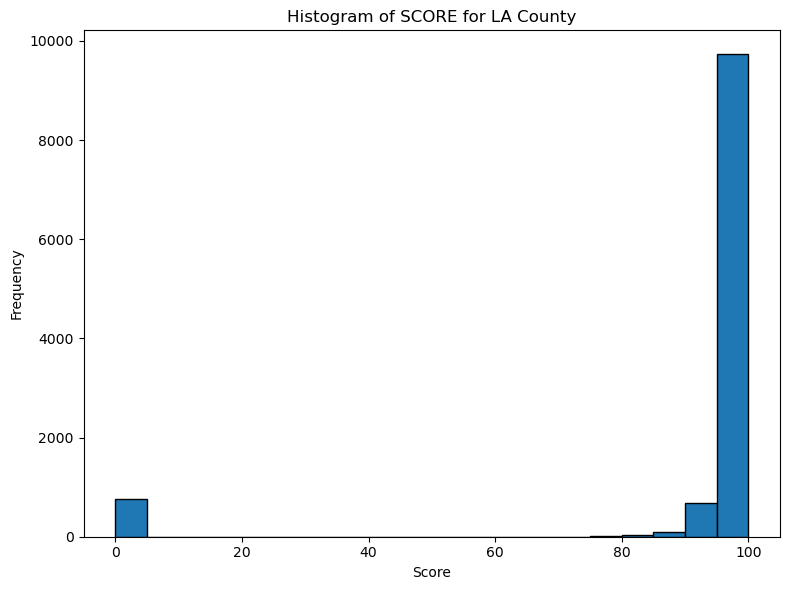

In [84]:
plt.figure(figsize=(8, 6))
lky_renamed['SCORE'].dropna().hist(bins=20, edgecolor='black')

plt.title('Histogram of SCORE for LA County')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(False)
plt.tight_layout()
plt.show()

# Austin Dataset

Toplines:
- Address needs a bit more cleaning, can use regular expressions to extract STREET_ADDRESS_LINE_2 and CITY from the "ADDRESS" variable
- Have data for 2022-2025


| InspDate_Year | Count |
|---------------|--------|
| 2022          | 6,939  |
| 2023          | 7,385  |
| 2024          | 6,777  |
| 2025          | 1,638  |


Link: https://data.austintexas.gov/Health-and-Community-Services/Food-Establishment-Inspection-Scores/ecmv-9xxi/about_data

In [86]:
#load raw data
raw_atx = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/Austin_Food_Establishment_Inspection_Scores_20250411.csv")

In [88]:
print(raw_atx.columns.tolist())


['Restaurant Name', 'Zip Code', 'Inspection Date', 'Score', 'Address', 'Facility ID', 'Process Description']


In [90]:
raw_atx['Process Description'].value_counts()

Process Description
Routine Inspection      22559
Follow-Up Inspection      180
Name: count, dtype: int64

Only two types: Routine Inspection or Follow-Up Inspection

In [89]:
#keep certain cols
atx_colstokeep = ['Restaurant Name', 'Zip Code', 'Inspection Date', 'Score', 'Address','Process Description']
atx_fewercols = raw_atx[atx_colstokeep]

In [91]:
print(atx_fewercols.columns.tolist())


['Restaurant Name', 'Zip Code', 'Inspection Date', 'Score', 'Address', 'Process Description']


In [94]:
#rename cols
atx_renamedict = {
    'Inspection Date': 'INSPECTION_DATE',
    'Restaurant Name': 'STORE_NAME',
    'FACILITY ADDRESS': 'STREET_ADDRESS',
    'Zip Code': 'ZIP5',
    'Process Description': 'ATX_SERVICE_DESCRIPTION',
    'Score': 'SCORE',
}
atx_renamed = atx_fewercols.rename(columns=atx_renamedict)

In [96]:
#clean INSPECTION_DATE
atx_renamed['INSPECTION_DATE'] = pd.to_datetime(
    atx_renamed['INSPECTION_DATE'],
    format='%m/%d/%Y'
)
#Creating new column with Year of Inspection Date
atx_renamed.loc[:,'INSPDATE_YEAR'] = atx_renamed['INSPECTION_DATE'].dt.year

In [97]:
#counts per year
atx_yearly_counts = atx_renamed.groupby('INSPDATE_YEAR').size()
# Display the result
print(atx_yearly_counts)

INSPDATE_YEAR
2022    6939
2023    7385
2024    6777
2025    1638
dtype: int64


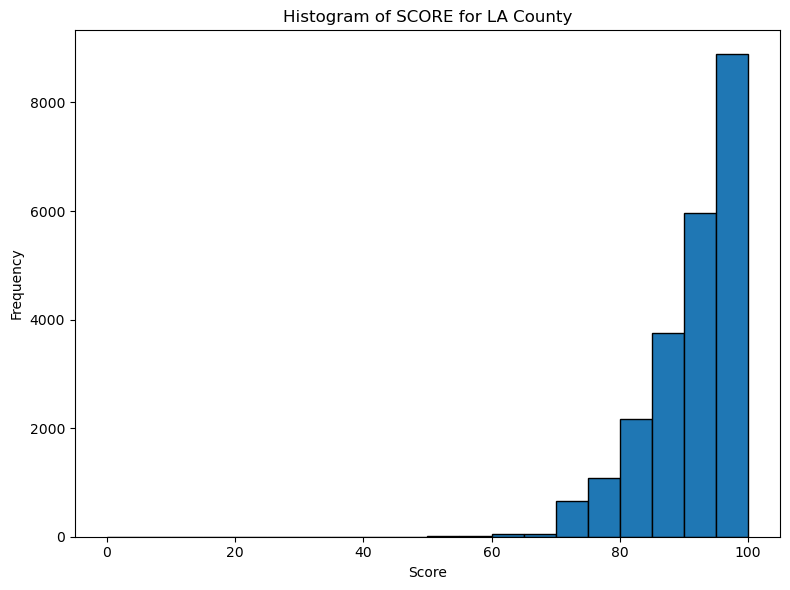

In [98]:
plt.figure(figsize=(8, 6))
atx_renamed['SCORE'].dropna().hist(bins=20, edgecolor='black')

plt.title('Histogram of SCORE for LA County')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(False)
plt.tight_layout()
plt.show()

# I do not recommend we use the datasets below. 

# Chicago Dataset

Topline Observations:
- This dataset already has latitude and longitude. 
- We should not use this data because it does not have a continuous restaurant grade variable.

### Analysis of Raw Data

In [20]:
#loading raw data
raw_chicago = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/Chicago_Food_Inspections.csv")
#filter to only restaurants
filtered_chicago = raw_chicago[raw_chicago["Facility Type"] == "Restaurant"]

In [15]:
filtered_chicago.describe()

,Inspection ID,License #,Zip,Latitude,Longitude
count,1.956100e+05,1.956100e+05,195589.000000,195400.000000,195400.000000
mean,1.830343e+06,1.816142e+06,60628.913594,41.888548,-87.675094
std,7.102181e+05,8.903514e+05,19.318503,0.075717,0.058592
min,4.424700e+04,0.000000e+00,60601.000000,41.644670,-87.906874
25%,1.375300e+06,1.495422e+06,60613.000000,41.853722,-87.703576
50%,2.028224e+06,2.083952e+06,60625.000000,41.895067,-87.663356
75%,2.501200e+06,2.438071e+06,60643.000000,41.941463,-87.634150
max,2.615470e+06,3.624677e+06,60827.000000,42.020808,-87.525094


In [16]:
filtered_chicago.shape


(195610, 17)

There are 195,610 restaurants in this Chicago dataset. The year range is 2010-2025.

In [26]:
print(filtered_chicago.columns.tolist())


['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Violations', 'Latitude', 'Longitude', 'Location', 'InspDate_Year']


In [21]:
#extracting year

#convert "Inspection Date" to datetime
filtered_chicago['Inspection Date'] = pd.to_datetime(filtered_chicago['Inspection Date'], format='%m/%d/%Y')
#Creating new column with Year of Inspection Date
filtered_chicago.loc[:,'InspDate_Year'] = filtered_chicago['Inspection Date'].dt.year

/var/folders/81/w_61xz297rv4ggdktb58tlxm0000gn/T/ipykernel_14584/2646666028.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_chicago['Inspection Date'] = pd.to_datetime(filtered_chicago['Inspection Date'], format='%m/%d/%Y')
/var/folders/81/w_61xz297rv4ggdktb58tlxm0000gn/T/ipykernel_14584/2646666028.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_chicago.loc[:,'InspDate_Year'] = filtered_chicago['Inspection Date'].dt.year


In [22]:
#filter to after 2019
filtered_chicago_2020on = filtered_chicago[filtered_chicago['InspDate_Year'] >= 2020]

In [23]:
#counts per year
yearly_counts = filtered_chicago_2020on.groupby('InspDate_Year').size()

# Or you can use .count() if you want to count non-null values for a specific column
# yearly_counts = filtered_chicago.groupby('InspDate_Year')['SomeColumn'].count()

# Display the result
print(yearly_counts)

InspDate_Year
2020     9620
2021    11111
2022    11833
2023    12663
2024    13614
2025     3290
dtype: int64


In [28]:
filtered_chicago_2020on.describe()

,Inspection ID,License #,Zip,Inspection Date,Latitude,Longitude,InspDate_Year
count,6.213100e+04,6.213100e+04,62130.000000,62131,62052.000000,62052.000000,62131.000000
mean,2.540569e+06,2.174984e+06,60628.920087,2022-10-17 13:54:38.653168128,41.887451,-87.675104,2022.312404
min,2.201212e+06,0.000000e+00,60601.000000,2020-01-02 00:00:00,41.644670,-87.906874,2020.000000
25%,2.522574e+06,1.981200e+06,60613.000000,2021-07-12 00:00:00,41.852526,-87.704130,2021.000000
50%,2.566888e+06,2.496202e+06,60625.000000,2022-11-09 00:00:00,41.895023,-87.663787,2022.000000
75%,2.589534e+06,2.749643e+06,60643.000000,2024-02-13 00:00:00,41.941943,-87.634330,2024.000000
max,2.615470e+06,3.624677e+06,60827.000000,2025-04-09 00:00:00,42.020808,-87.525094,2025.000000
std,7.257362e+04,8.557074e+05,19.160985,NaN,0.076626,0.057882,1.502486


Looks like there are lots of inspections per year.

In [29]:
print(filtered_chicago_2020on.columns.tolist())


['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Violations', 'Latitude', 'Longitude', 'Location', 'InspDate_Year']


## Looking into outcome data - Chicago Dataset

- does not have a numerical score
- Possible variables we could use
    - `Risk`: Values are "Risk 1 (High)", "Risk 2 (Medium)", "Risk 3 (Low)"
    - `Results`: "Pass", "Fail", "Pass w/ Conditions", "Other"
    

In [32]:
risk_counts_per_year = filtered_chicago_2020on.groupby('InspDate_Year')['Risk'].value_counts()
# Display the result
print(risk_counts_per_year)

InspDate_Year  Risk           
2020           Risk 1 (High)       7573
               Risk 2 (Medium)     1929
               Risk 3 (Low)         118
2021           Risk 1 (High)       9352
               Risk 2 (Medium)     1656
               Risk 3 (Low)         103
2022           Risk 1 (High)       9869
               Risk 2 (Medium)     1872
               Risk 3 (Low)          88
               All                    4
2023           Risk 1 (High)      10991
               Risk 2 (Medium)     1568
               Risk 3 (Low)         101
               All                    2
2024           Risk 1 (High)      11276
               Risk 2 (Medium)     2077
               Risk 3 (Low)         261
2025           Risk 1 (High)       2896
               Risk 2 (Medium)      305
               Risk 3 (Low)          89
Name: count, dtype: int64


In [ ]:
results_counts_per_year = filtered_chicago_2020on.groupby('InspDate_Year')['Results'].value_counts()
# Display the result
print(results_counts_per_year)

InspDate_Year  Results             
2020           Pass                    3647
               Pass w/ Conditions      2585
               Fail                    1798
               Out of Business          743
               No Entry                 620
               Not Ready                226
               Business Not Located       1
2021           Pass                    4520
               Pass w/ Conditions      2370
               Fail                    2076
               No Entry                 967
               Out of Business          937
               Not Ready                241
2022           Pass                    5456
               Fail                    2441
               Pass w/ Conditions      1914
               No Entry                 909
               Out of Business          908
               Not Ready                204
               Business Not Located       1
2023           Pass                    6138
               Fail                    2

# Boston Dataset

Bosston does not have the dependent variables we need. 

# NYC Dataset

Topline Observations:
- This dataset already has latitude and longitude. 
- The scoring system is very different from other cities and the scoring data seems very dirty -- would not recommend that we use it. 

In [24]:
#load data
raw_nyc = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/DOHMH_New_York_City_Restaurant_Inspection_Results_20250411.csv")

In [25]:
# get cols
print(raw_nyc.columns.tolist())


['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE', 'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE', 'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE', 'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude', 'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL', 'NTA', 'Location Point1']


In [37]:
#extracting year

#convert "Inspection Date" to datetime
raw_nyc['Inspection Date'] = pd.to_datetime(raw_nyc['INSPECTION DATE'], format='%m/%d/%Y')

In [40]:
print(raw_nyc.dtypes)


CAMIS                             int64
DBA                              object
BORO                             object
BUILDING                         object
STREET                           object
ZIPCODE                         float64
PHONE                            object
CUISINE DESCRIPTION              object
INSPECTION DATE                  object
ACTION                           object
VIOLATION CODE                   object
VIOLATION DESCRIPTION            object
CRITICAL FLAG                    object
SCORE                           float64
GRADE                            object
GRADE DATE                       object
RECORD DATE                      object
INSPECTION TYPE                  object
Latitude                        float64
Longitude                       float64
Community Board                 float64
Council District                float64
Census Tract                    float64
BIN                             float64
BBL                             float64


In [39]:
#Creating new column with Year of Inspection Date
raw_nyc.loc[:,'InspDate_Year'] = raw_nyc['Inspection Date'].dt.year

In [41]:
#counts per year
yearly_counts = raw_nyc.groupby('InspDate_Year').size()
# Display the result
print(yearly_counts)

InspDate_Year
1900     3143
2015       18
2016      264
2017      590
2018      919
2019     1235
2020      612
2021     9248
2022    69617
2023    72959
2024    92522
2025    26355
dtype: int64


Lots of year data. Let's focus on 2020 on?

In [42]:
#filter to after 2019
filtered_nyc_2020on = raw_nyc[raw_nyc['InspDate_Year'] >= 2020]

In [44]:
filtered_nyc_2020on.shape

(271313, 29)

### Outcomes Variables - NYC Dataset

- Possible variables we could use
    - `SCORE`: The minimum value is 0.0. The maximum value is 168.0. It is unclear how these are scaled. 1,236 of the inspection SCOREs between 2020-2025 are above 100. 
    - `GRADE`: "A", "N", "B", "C", "P", "Z".

In [47]:
print(filtered_nyc_2020on['SCORE'].min())
print(filtered_nyc_2020on['SCORE'].max())
print((filtered_nyc_2020on['SCORE'] > 100).sum()
)

0.0
168.0
1236


In [45]:
grade_counts_per_year = filtered_nyc_2020on.groupby('InspDate_Year')['GRADE'].value_counts()
# Display the result
print(grade_counts_per_year)

InspDate_Year  GRADE
2020           A          181
               N           44
               B           35
               C           27
               P            1
2021           A         3269
               B          252
               C          129
               P           48
               N           28
2022           A        24529
               B         3748
               C         2264
               P          401
               N          157
               Z           57
2023           A        25064
               B         5598
               C         3361
               N         1265
               P          240
               Z          208
2024           A        30624
               B         5665
               C         4072
               N         3515
               Z         2651
               P          184
2025           A         8046
               N         3158
               Z         2554
               B          896
               C   

In [50]:
test = raw_nyc[raw_nyc['InspDate_Year'] >= 2022]

In [51]:
counts = test['SCORE'].value_counts()
print(counts)

SCORE
12.0     21914
13.0     21129
10.0     10239
11.0      9408
9.0       8618
         ...  
116.0       11
141.0        9
122.0        8
153.0        7
117.0        5
Name: count, Length: 138, dtype: int64


# Merging Data